# Full EDA for `dataset.csv`

This notebook performs a complete exploratory data analysis for the dataset in `mlops/data/dataset.csv`.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from IPython.display import display

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)

DATA_PATH = Path('data/dataset.csv')
TARGET_COL = None  # set manually if needed, e.g. 'target'

if not DATA_PATH.exists():
    raise FileNotFoundError(f'Dataset not found: {DATA_PATH.resolve()}')

print('Using dataset:', DATA_PATH.resolve())

Using dataset: C:\Users\markiian_leshchyshyn\Documents\NULP\LABS\4year_2sem\MLOPS\mlops\data\dataset.csv


In [2]:
df = pd.read_csv(DATA_PATH, low_memory=False)

print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns')
display(df.head())
display(df.sample(min(5, len(df)), random_state=42))

Shape: 50,000 rows x 2 columns


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


,review,sentiment
33553,I really liked this Summerslam due to the look...,positive
9427,Not many television shows appeal to quite as m...,positive
199,The film quickly gets to a major chase scene w...,negative
12447,Jane Austen would definitely approve of this o...,positive
39489,Expectations were somewhat high for me when I ...,negative


In [3]:
# Basic structure and memory profile
dtype_df = pd.DataFrame({
    'column': df.columns,
    'dtype': df.dtypes.astype(str).values,
    'non_null': df.notna().sum().values,
    'null': df.isna().sum().values,
    'null_%': (df.isna().mean() * 100).round(2).values,
    'n_unique': df.nunique(dropna=True).values
}).sort_values(['null_%', 'n_unique'], ascending=[False, True])

mem_mb = df.memory_usage(deep=True).sum() / 1024**2
print(f'Total memory usage: {mem_mb:.2f} MB')
display(dtype_df)

Total memory usage: 76.97 MB


,column,dtype,non_null,null,null_%,n_unique
1,sentiment,str,50000,0,0.0,2
0,review,str,50000,0,0.0,49582


In [4]:
# Duplicate checks
dup_rows = df.duplicated().sum()
dup_ratio = dup_rows / len(df) * 100
print(f'Duplicate rows: {dup_rows:,} ({dup_ratio:.2f}%)')

constant_cols = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
print(f'Constant columns: {len(constant_cols)}')
if constant_cols:
    display(pd.Series(constant_cols, name='constant_columns'))

Duplicate rows: 418 (0.84%)
Constant columns: 0


In [5]:
# Column type split
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
dt_cols = df.select_dtypes(include=['datetime64[ns]', 'datetime64[ns, UTC]']).columns.tolist()

print(f'Numeric columns: {len(num_cols)}')
print(f'Categorical/Object/Bool columns: {len(cat_cols)}')
print(f'Datetime columns: {len(dt_cols)}')

Numeric columns: 0
Categorical/Object/Bool columns: 2
Datetime columns: 0


In [6]:
# Categorical summary and cardinality
if cat_cols:
    cat_summary = pd.DataFrame({
        'column': cat_cols,
        'n_unique': [df[c].nunique(dropna=True) for c in cat_cols],
        'missing_%': [(df[c].isna().mean() * 100) for c in cat_cols],
        'top_value': [df[c].mode(dropna=True).iloc[0] if not df[c].mode(dropna=True).empty else np.nan for c in cat_cols],
        'top_freq': [df[c].value_counts(dropna=True).iloc[0] if not df[c].value_counts(dropna=True).empty else 0 for c in cat_cols],
    }).sort_values(['n_unique', 'missing_%'], ascending=[False, False])
    cat_summary['missing_%'] = cat_summary['missing_%'].round(2)
    display(cat_summary)
else:
    print('No categorical columns found.')

,column,n_unique,missing_%,top_value,top_freq
0,review,49582,0.0,Loved today's show!!! It was a variety and not...,5
1,sentiment,2,0.0,negative,25000


In [7]:
import sys, matplotlib, seaborn
print(sys.executable)
print(matplotlib.__version__)
print(seaborn.__version__)


c:\Users\markiian_leshchyshyn\Documents\NULP\LABS\4year_2sem\MLOPS\mlops\.venv\Scripts\python.exe
3.10.8
0.13.2


Text(0.5, 1.03, "Розподіл кількості символів у 'review'")

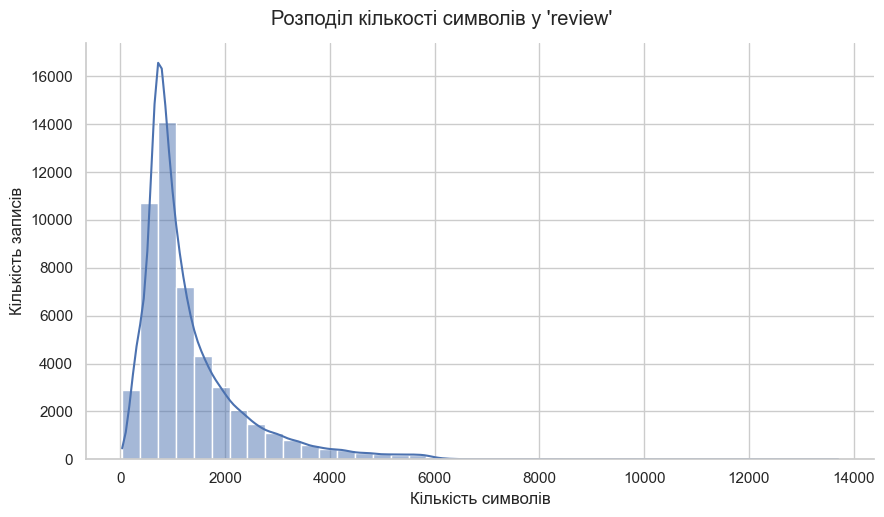

In [ ]:
import seaborn as sns

TEXT_COL = "review"  
char_len = df[TEXT_COL].fillna("").astype(str).str.len()

g = sns.displot(char_len, bins=40, kde=True, height=5, aspect=1.8)
g.set_axis_labels("Кількість символів", "Кількість записів")
g.fig.suptitle(f"Розподіл кількості символів у '{TEXT_COL}'", y=1.03)

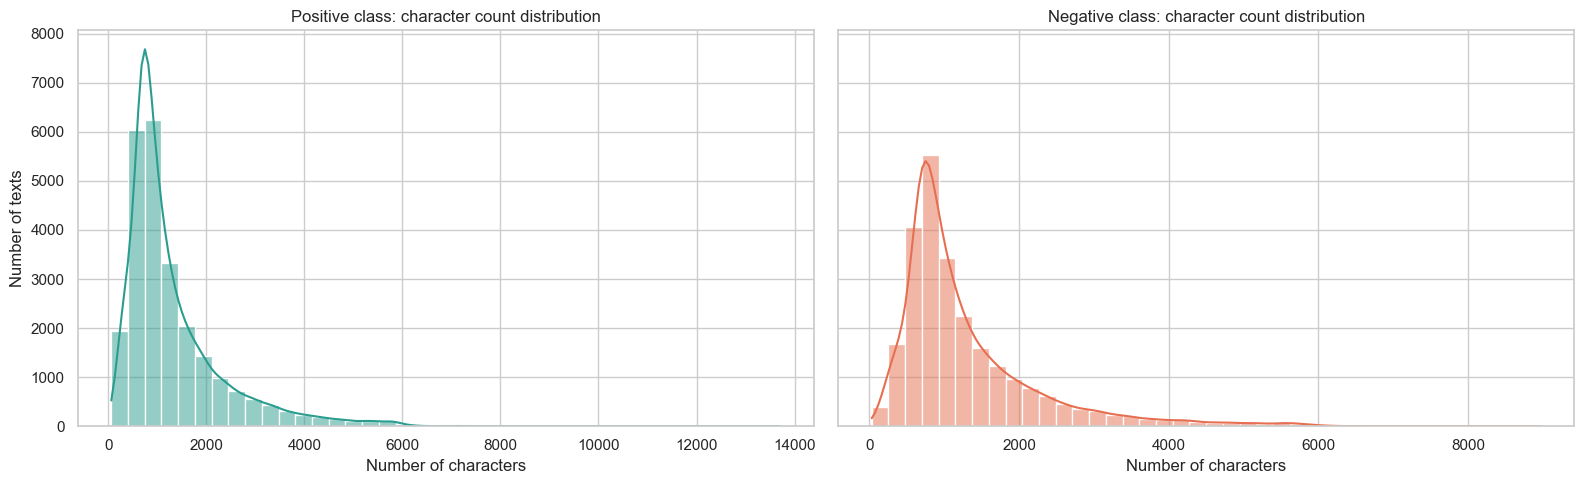

,count,mean,std,min,25%,50%,75%,max
sentiment,,,,,,,,
negative,25000.0,1294.06436,945.892669,32.0,706.0,973.0,1567.25,8969.0
positive,25000.0,1324.79768,1031.492627,65.0,691.0,968.0,1614.00,13704.0


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

TEXT_COL = "review"
TARGET_COL = "sentiment"

# Prepare data
plot_df = df[[TEXT_COL, TARGET_COL]].dropna().copy()
plot_df[TARGET_COL] = plot_df[TARGET_COL].astype(str).str.strip().str.lower()
plot_df["char_len"] = plot_df[TEXT_COL].astype(str).str.len()

pos = plot_df.loc[plot_df[TARGET_COL] == "positive", "char_len"]
neg = plot_df.loc[plot_df[TARGET_COL] == "negative", "char_len"]

# Separate distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

sns.histplot(pos, bins=40, kde=True, color="#2a9d8f", ax=axes[0])
axes[0].set_title("Positive class: character count distribution")
axes[0].set_xlabel("Number of characters")
axes[0].set_ylabel("Number of texts")

sns.histplot(neg, bins=40, kde=True, color="#e76f51", ax=axes[1])
axes[1].set_title("Negative class: character count distribution")
axes[1].set_xlabel("Number of characters")

plt.tight_layout()
plt.show()

# Optional summary stats
display(plot_df.groupby(TARGET_COL)["char_len"].describe())